# **LEVEL 1:**

# **Task 1: Data Exploration and Preprocessing**


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from google.colab import files
uploaded = files.upload()


Saving Dataset .csv to Dataset  (2).csv


In [48]:
df = pd.read_csv("Dataset .csv")

In [49]:
df.shape

(8917, 21)

In [50]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8917 entries, 0 to 8916
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         8917 non-null   int64  
 1   Restaurant Name       8917 non-null   object 
 2   Country Code          8917 non-null   int64  
 3   City                  8917 non-null   object 
 4   Address               8917 non-null   object 
 5   Locality              8917 non-null   object 
 6   Locality Verbose      8917 non-null   object 
 7   Longitude             8917 non-null   float64
 8   Latitude              8917 non-null   float64
 9   Cuisines              8907 non-null   object 
 10  Average Cost for two  8916 non-null   float64
 11  Currency              8916 non-null   object 
 12  Has Table booking     8916 non-null   object 
 13  Has Online delivery   8916 non-null   object 
 14  Is delivering now     8916 non-null   object 
 15  Switch to order menu 

# **Check Missing Values**

In [52]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,10


In [53]:
df = df.fillna(df.mean(numeric_only=True))

In [54]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [55]:
df.dropna(inplace=True)


# **Convert Data Types**

In [56]:
df["Aggregate rating"] = pd.to_numeric(df["Aggregate rating"], errors="coerce")


In [57]:
df["Restaurant ID"] = df["Restaurant ID"].astype("category")

# **Analyze the Target Variable — "Aggregate rating"**

In [58]:
df["Aggregate rating"].describe()


,Aggregate rating
count,8917.000000
mean,2.620738
std,1.511742
min,0.000000
25%,2.400000
50%,3.200000
75%,3.600000
max,4.900000


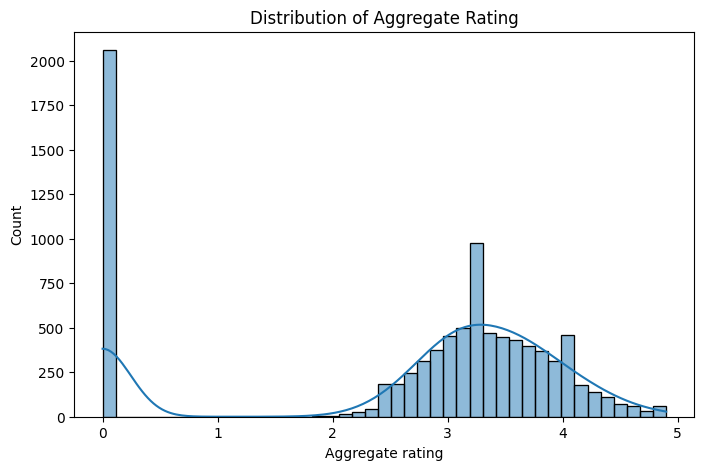

In [59]:
plt.figure(figsize=(8,5))
sns.histplot(df["Aggregate rating"], kde=True)
plt.title("Distribution of Aggregate Rating")
plt.show()


# **Check Class Imbalance**

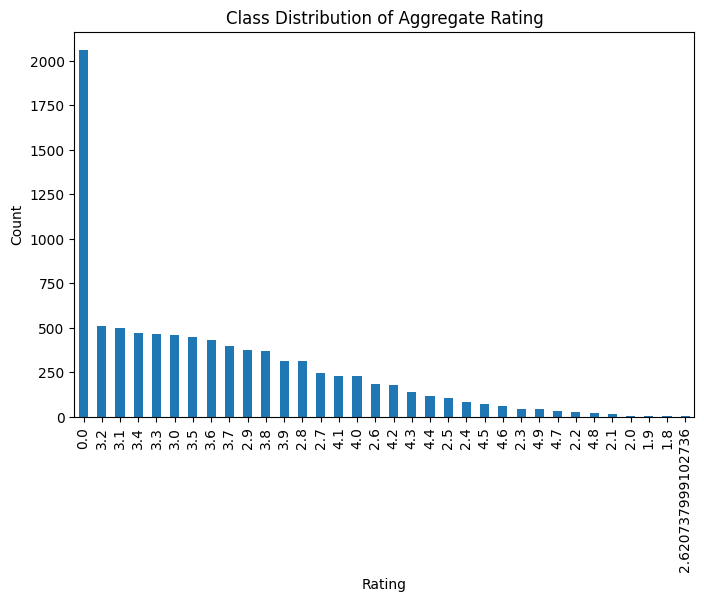

In [60]:
df["Aggregate rating"].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Class Distribution of Aggregate Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [61]:
df["rating_bin"] = pd.cut(df["Aggregate rating"],
                          bins=[0,2,3.5,5],
                          labels=["Low","Medium","High"])

df["rating_bin"].value_counts()


,count
rating_bin,
Medium,4228
High,2621
Low,7


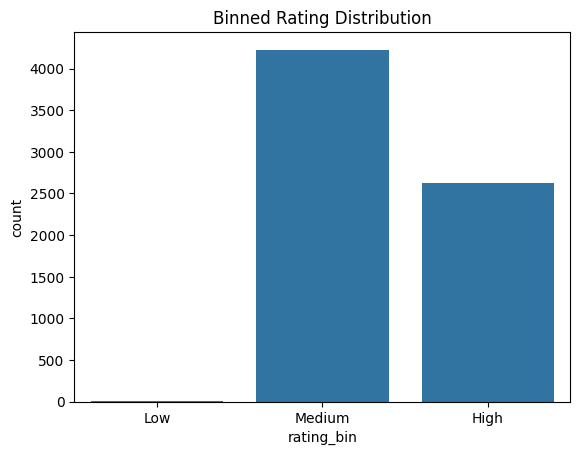

In [62]:
sns.countplot(x="rating_bin", data=df)
plt.title("Binned Rating Distribution")
plt.show()


✔ Number of rows & columns
✔ List of columns & data types
✔ Missing value table + how you handled them
✔ Any data type changes
✔ Distribution plot of "Aggregate rating"
✔ Class imbalance explanation **bold text**

# **Task 2: Descriptive Analysis**

#  Basic Statistical Measures

In [63]:
df.describe()

,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,8917.000000,8917.000000,8917.000000,8917.000000,8917.000000,8917.000000,8917.000000
mean,13.951441,64.369514,26.490193,585.694594,1.755271,2.620738,152.451660
std,50.332894,41.208514,8.688173,602.802758,0.877284,1.511742,435.980476
min,1.000000,-157.948486,-38.634746,0.000000,1.000000,0.000000,0.000000
25%,1.000000,77.086466,28.492435,250.000000,1.000000,2.400000,4.000000
50%,1.000000,77.191560,28.573224,400.000000,2.000000,3.200000,27.000000
75%,1.000000,77.268938,28.643732,700.000000,2.000000,3.600000,119.000000
max,216.000000,153.593331,52.008289,8000.000000,4.000000,4.900000,10934.000000


In [64]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Country Code', 'Longitude', 'Latitude', 'Average Cost for two',
       'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')

In [65]:
stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std Dev": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max()
})

stats


,Mean,Median,Std Dev,Min,Max
Country Code,13.951441,1.000000,50.332894,1.000000,216.000000
Longitude,64.369514,77.191560,41.208514,-157.948486,153.593331
Latitude,26.490193,28.573224,8.688173,-38.634746,52.008289
Average Cost for two,585.694594,400.000000,602.802758,0.000000,8000.000000
Price range,1.755271,2.000000,0.877284,1.000000,4.000000
Aggregate rating,2.620738,3.200000,1.511742,0.000000,4.900000
Votes,152.451660,27.000000,435.980476,0.000000,10934.000000


# **Explore Categorical Variables Distribution**

In [66]:
df["Country Code"].value_counts()

,count
Country Code,
1,8293
216,434
214,60
30,60
14,24
162,22
184,20
37,4


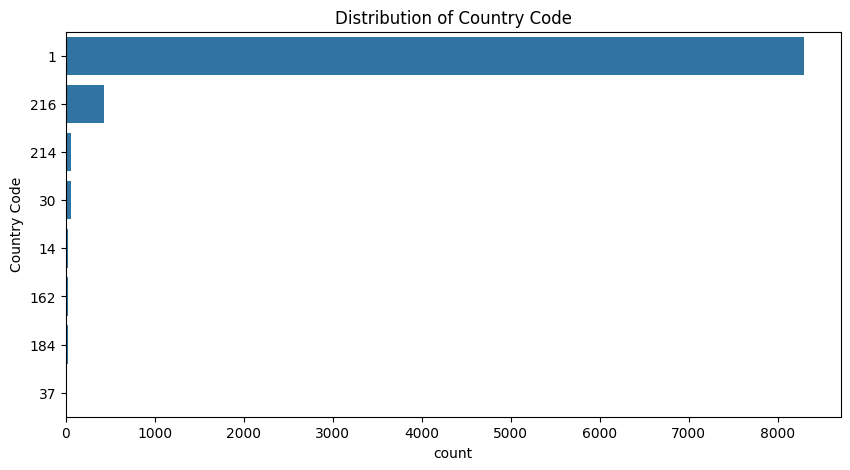

In [67]:
plt.figure(figsize=(10,5))
sns.countplot(y=df["Country Code"], order=df["Country Code"].value_counts().index)
plt.title("Distribution of Country Code")
plt.show()


In [68]:
df["City"].value_counts().head(20)


,count
City,
New Delhi,5473
Gurgaon,1118
Noida,884
Faridabad,251
Ghaziabad,25
Ahmedabad,21
Amritsar,21
Guwahati,21
Lucknow,21


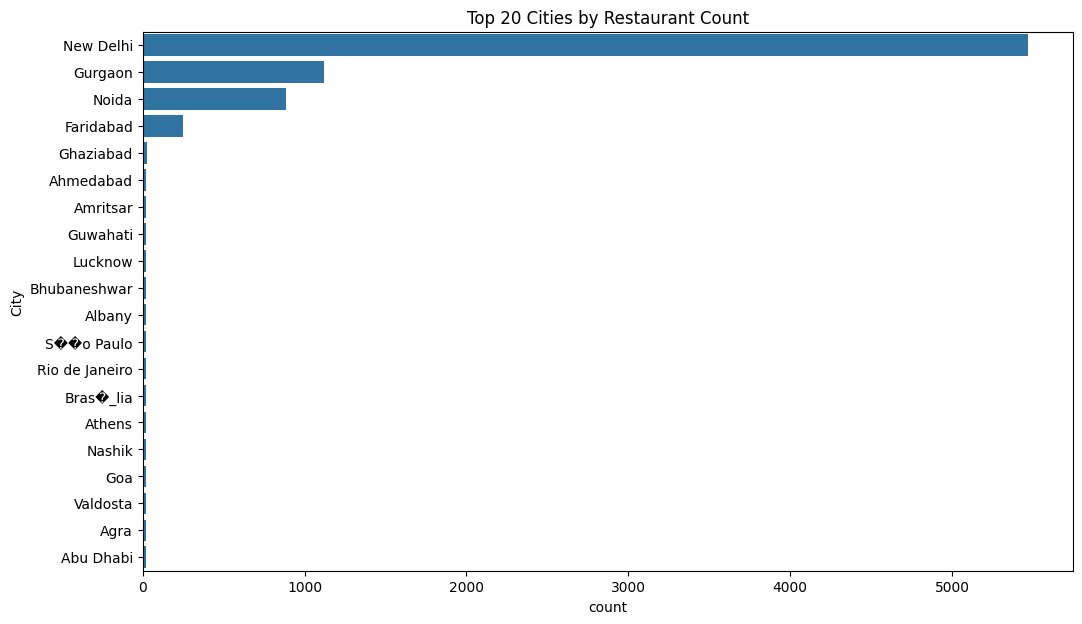

In [69]:
plt.figure(figsize=(12,7))
sns.countplot(y=df["City"], order=df["City"].value_counts().head(20).index)
plt.title("Top 20 Cities by Restaurant Count")
plt.show()


# **Cuisines Distribution**

# **Split cuisines into individual items:**

In [70]:
cuisine_series = df['Cuisines'].str.split(',').explode().str.strip()


# **Count top cuisines**

In [71]:
cuisine_series.value_counts().head(20)


,count
Cuisines,
North Indian,3779
Chinese,2606
Fast Food,1909
Mughlai,951
Bakery,713
Italian,695
Continental,688
Cafe,615
Desserts,604


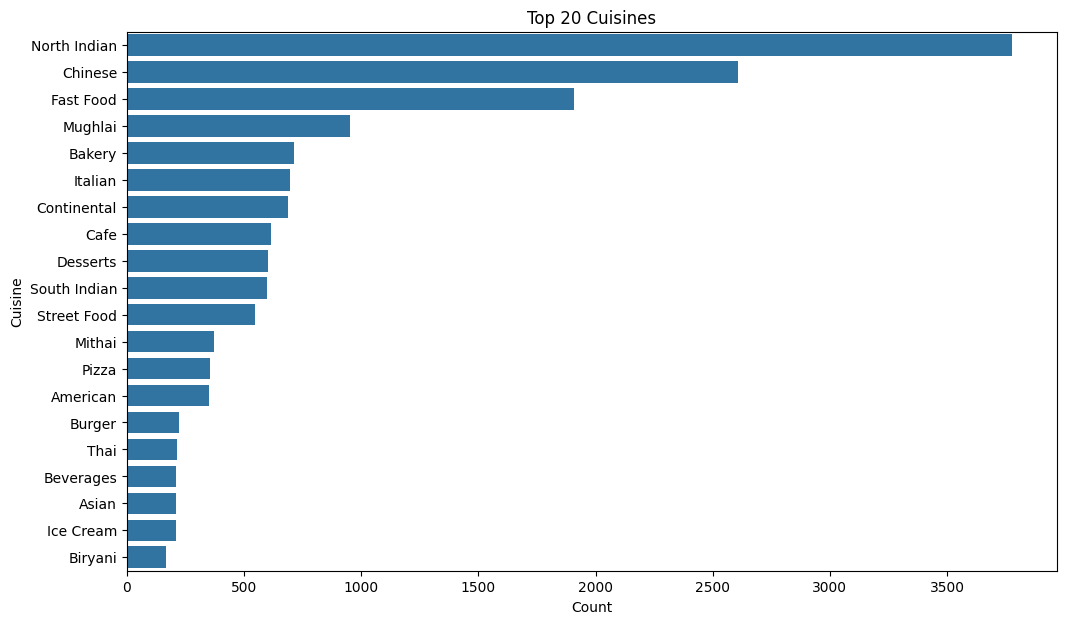

In [72]:
top_cuisines = cuisine_series.value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 20 Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()


# **Identify Top Cuisines & Top Cities**

# **Top 10 Cities with Most Restaurants**

In [73]:
top_cities = df["City"].value_counts().head(10)
top_cities

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,884
Faridabad,251
Ghaziabad,25
Ahmedabad,21
Amritsar,21
Guwahati,21
Lucknow,21


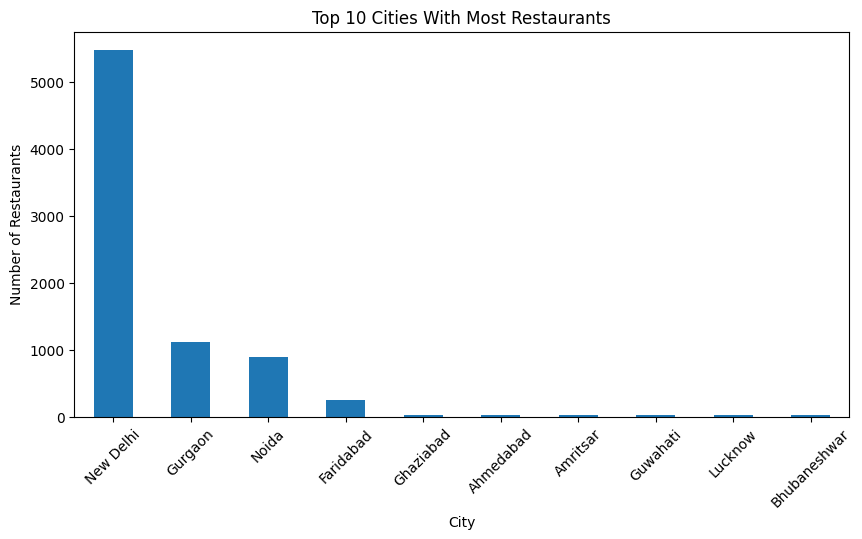

In [74]:
plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Cities With Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()


# **Top 10 Cuisines**

In [75]:
top_cuisines = cuisine_series.value_counts().head(10)
top_cuisines

,count
Cuisines,
North Indian,3779
Chinese,2606
Fast Food,1909
Mughlai,951
Bakery,713
Italian,695
Continental,688
Cafe,615
Desserts,604


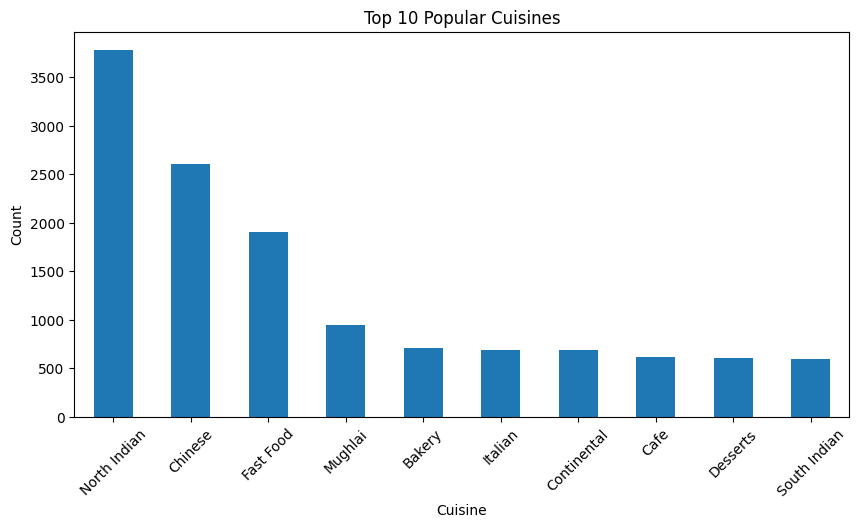

In [76]:
plt.figure(figsize=(10,5))
top_cuisines.plot(kind='bar')
plt.title("Top 10 Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

✔ Statistical summary (mean, median, std) ✔ Distribution plots for:

Country Code

City

Cuisines ✔ Top cities ✔ Top cuisines **bold text**

# **Task 3: Geospatial Analysis**

In [77]:
!pip install folium

In [78]:
import folium

In [79]:
world_map = folium.Map(location=[20,0], zoom_start=2)

In [80]:
for i, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2,
        color='red',
        fill=True
    ).add_to(world_map)

world_map

# **Distribution of Restaurants by City & Country**

# **Restaurants per Country**

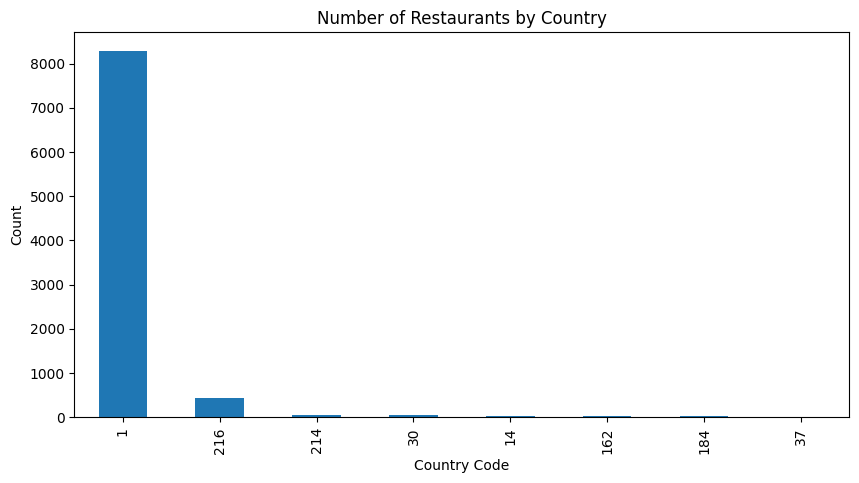

In [81]:
df["Country Code"].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Number of Restaurants by Country")
plt.xlabel("Country Code")
plt.ylabel("Count")
plt.show()


# **Restaurants per City**

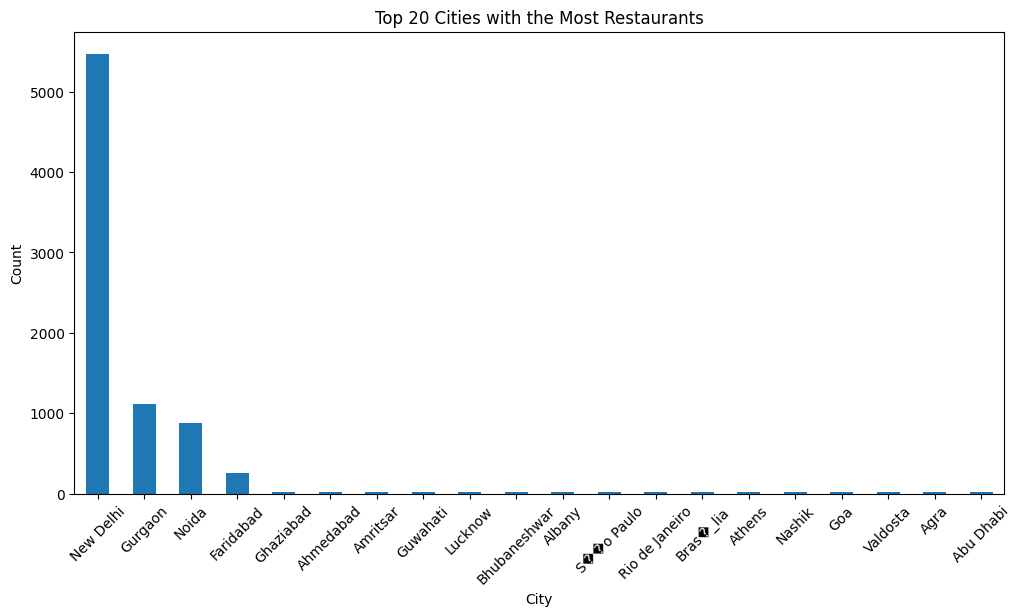

In [82]:
df["City"].value_counts().head(20).plot(kind='bar', figsize=(12,6))
plt.title("Top 20 Cities with the Most Restaurants")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# **Correlation Between Location (Lat/Long) & Rating**

# **Correlation Heatmap**

In [83]:
df[["Latitude", "Longitude", "Aggregate rating"]].corr()


,Latitude,Longitude,Aggregate rating
Latitude,1.000000,0.143628,0.069022
Longitude,0.143628,1.000000,-0.119940
Aggregate rating,0.069022,-0.119940,1.000000


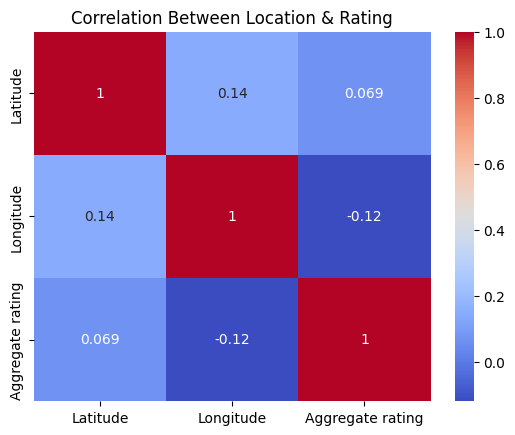

In [84]:
sns.heatmap(df[["Latitude", "Longitude", "Aggregate rating"]].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Location & Rating")
plt.show()

# **Scatter Plots**

# **Latitude vs Rating**

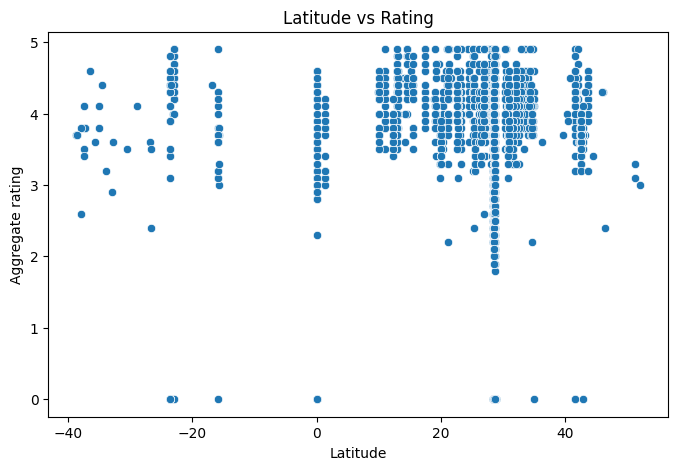

In [85]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Latitude"], y=df["Aggregate rating"])
plt.title("Latitude vs Rating")
plt.show()


# **Longitude vs Rating**

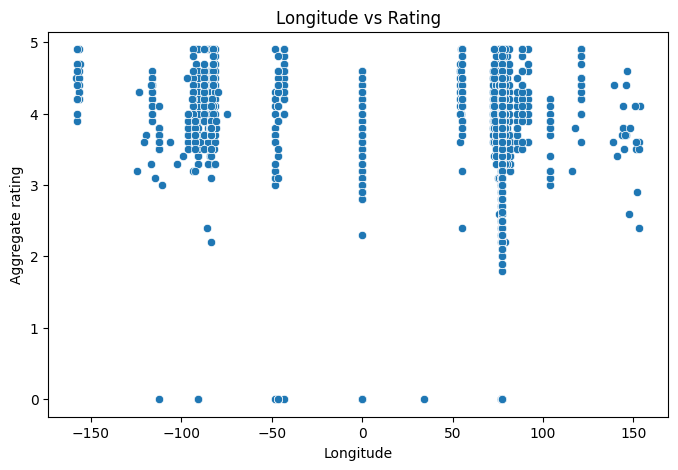

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Longitude"], y=df["Aggregate rating"])
plt.title("Longitude vs Rating")
plt.show()


✔ A map visualization of restaurant locations ✔ A plot showing restaurant distribution across cities/countries ✔ A correlation heatmap between latitude/longitude & ratings ✔ Interpretation:

Do certain countries/cities have more restaurants?

Is rating influenced by geolocation? (Usually very weak correlation)